# Оптимизация SQL-запросов в PostgreSQL: теория и практика на реальном сервере

Это продолжение ноутбука [`query_optimization.ipynb`](query_optimization.ipynb) (та же тема на
SQLite). Здесь используется **настоящий PostgreSQL-сервер**, поднятый в Docker, и подключение
через `psycopg2`. Смысл в том, чтобы увидеть вещи, которых в SQLite просто нет: несколько
алгоритмов JOIN (Nested Loop / Hash Join / Merge Join), параллельное выполнение запросов,
`Buffers: shared hit/read` (что реально попало в кеш, а что читалось с диска), spill сортировки
на диск при нехватке `work_mem`, покрывающие индексы с `INCLUDE`, требование `VACUUM` для
Index Only Scan, партиционированные (partial) и BRIN-индексы.

## Как поднят сервер

```bash
docker run -d \
  --name tutor-pg-optimization \
  -e POSTGRES_USER=tutor \
  -e POSTGRES_PASSWORD=tutor \
  -e POSTGRES_DB=optimization \
  -p 127.0.0.1:5433:5432 \
  postgres:16-alpine
```

Понадобится ещё Python-драйвер: `pip install psycopg2-binary`.

Контейнер слушает **только на localhost:5433**, наружу не смотрит. Если вы перезапускаете
ноутбук на новой машине — сначала выполните эту команду в терминале (или посмотрите раздел
"Управление контейнером" в конце ноутбука).

## План курса

1. Подключение и загрузка тестовых данных (`COPY`, а не построчные `INSERT`)
2. `EXPLAIN (ANALYZE, BUFFERS)`: как читать план на реальном сервере
3. Full scan vs индекс
4. Sargable-выражения
5. Составные индексы и leftmost prefix
6. Покрывающие индексы (`INCLUDE`) и почему для них важен `VACUUM`
7. JOIN: Nested Loop vs Hash Join vs Merge Join
8. Проблема N+1 — теперь по-настоящему, по сети
9. Подзапросы: `IN` / `EXISTS` / `JOIN` / `CTE` (и `MATERIALIZED`)
10. `LIKE`, коллации и `pg_trgm`
11. Пагинация: `OFFSET/LIMIT` vs keyset
12. Агрегация, `work_mem` и spill на диск
13. Partial-индексы
14. Типы индексов: B-tree, GIN, BRIN — точность вместо размера
15. `ANALYZE`, `pg_stat_user_tables` и мёртвые строки (dead tuples)
16. Бонус: параллельное выполнение запросов
17. Итоговая сводка измерений
18. Памятка и отличия от SQLite-версии
19. Задания для самостоятельной работы
20. Управление контейнером

In [1]:
import psycopg2
import time
import random
import io
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
random.seed(42)

conn = psycopg2.connect(host="127.0.0.1", port=5433, user="tutor", password="tutor", dbname="optimization")
conn.autocommit = True   # для учебных целей: каждая DDL/DML команда применяется сразу
cur = conn.cursor()

# Отключаем параллельное выполнение на время основной части ноутбука — с ним планы
# получаются сложнее (Gather, несколько Workers), и сравнивать "было/стало" труднее.
# Параллелизм отдельно разберём как бонус в разделе 16.
cur.execute("SET max_parallel_workers_per_gather = 0")

results = []
def record(name, seconds, note=""):
    results.append({"experiment": name, "time_ms": seconds * 1000, "note": note})
    print(f"{name}: {seconds*1000:.2f} ms  {note}")

## 1. Схема и загрузка данных

Та же схема интернет-магазина, что и в SQLite-версии: `customers`, `products`, `orders`,
`order_items`. Для загрузки **не используем** `executemany`/построчные `INSERT` — на реальном
сервере по сети это будет на порядок медленнее. Используем `COPY FROM STDIN` — тот же механизм,
которым пользуется `pg_restore` и большинство ETL-инструментов для быстрой массовой загрузки.

In [2]:
cur.execute("DROP TABLE IF EXISTS order_items, orders, products, customers CASCADE")
cur.execute('''
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    full_name   TEXT NOT NULL,
    city        TEXT NOT NULL,
    signup_date DATE NOT NULL
);
CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    name       TEXT NOT NULL,
    category   TEXT NOT NULL,
    price      NUMERIC(10,2) NOT NULL
);
CREATE TABLE orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    order_date  DATE NOT NULL,
    status      TEXT NOT NULL
);
CREATE TABLE order_items (
    order_item_id INTEGER PRIMARY KEY,
    order_id      INTEGER NOT NULL,
    product_id    INTEGER NOT NULL,
    quantity      INTEGER NOT NULL,
    unit_price    NUMERIC(10,2) NOT NULL
);
''')

FIRST_NAMES = ["Александр", "Мария", "Дмитрий", "Елена", "Сергей", "Анна", "Иван",
               "Ольга", "Максим", "Наталья", "Андрей", "Татьяна", "Павел", "Ирина",
               "Артём", "Светлана", "Николай", "Юлия", "Виктор", "Екатерина"]
LAST_NAMES = ["Иванов", "Петров", "Сидоров", "Смирнов", "Кузнецов", "Попов",
              "Соколов", "Лебедев", "Козлов", "Новиков", "Морозов", "Волков",
              "Соловьёв", "Васильев", "Зайцев", "Павлов", "Семёнов", "Голубев"]
CITIES = ["Москва", "Санкт-Петербург", "Новосибирск", "Екатеринбург", "Казань",
          "Нижний Новгород", "Челябинск", "Самара", "Омск", "Ростов-на-Дону"]
CATEGORIES = ["Электроника", "Одежда", "Дом и сад", "Книги", "Спорт",
              "Красота", "Игрушки", "Продукты", "Автотовары", "Зоотовары"]
STATUSES = ["new", "paid", "shipped", "delivered", "cancelled"]

N_CUSTOMERS = 20_000
N_PRODUCTS = 3_000
N_ORDERS = 200_000

def copy_rows(table, rows):
    buf = io.StringIO()
    for row in rows:
        buf.write("\t".join(str(v) for v in row) + "\n")
    buf.seek(0)
    cur.copy_expert(f"COPY {table} FROM STDIN WITH (FORMAT text)", buf)

t0 = time.perf_counter()

copy_rows("customers", (
    (i, f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}", random.choice(CITIES),
     f"20{random.randint(20,25)}-{random.randint(1,12):02d}-{random.randint(1,28):02d}")
    for i in range(1, N_CUSTOMERS + 1)
))

copy_rows("products", (
    (i, f"{random.choice(CATEGORIES)} товар #{i}", random.choice(CATEGORIES),
     round(random.uniform(100, 50000), 2))
    for i in range(1, N_PRODUCTS + 1)
))

def random_date_2024_2025():
    year = random.choice([2024, 2025])
    return f"{year}-{random.randint(1,12):02d}-{random.randint(1,28):02d}"

copy_rows("orders", (
    (i, random.randint(1, N_CUSTOMERS), random_date_2024_2025(), random.choice(STATUSES))
    for i in range(1, N_ORDERS + 1)
))

def gen_order_items():
    item_id = 1
    for order_id in range(1, N_ORDERS + 1):
        for _ in range(random.randint(1, 5)):
            yield (item_id, order_id, random.randint(1, N_PRODUCTS),
                   random.randint(1, 5), round(random.uniform(100, 50000), 2))
            item_id += 1

copy_rows("order_items", gen_order_items())

cur.execute("SELECT count(*) FROM order_items")
n_items = cur.fetchone()[0]
cur.execute("ANALYZE")
print(f"Загружено за {time.perf_counter()-t0:.1f} c")
print(f"customers: {N_CUSTOMERS:,}  products: {N_PRODUCTS:,}  "
      f"orders: {N_ORDERS:,}  order_items: {n_items:,}")

Загружено за 4.1 c
customers: 20,000  products: 3,000  orders: 200,000  order_items: 600,401


## 2. `EXPLAIN (ANALYZE, BUFFERS)`: как читать план на реальном сервере

В отличие от `EXPLAIN QUERY PLAN` в SQLite, PostgreSQL умеет **на самом деле выполнить**
запрос и показать реальные цифры (`ANALYZE`), а не только оценки планировщика:

- **`cost=0.00..3764.00`** — оценка планировщика (условные единицы, не мс): `startup cost` до
  первой строки и `total cost` до последней. Используется *только* для сравнения альтернативных
  планов между собой планировщиком, не как абсолютное время.
- **`actual time=1.402..10.141`** — а это уже реальное время в мс: до первой строки и до конца.
- **`rows=7 loops=1`** — сколько строк реально вернул этот узел и сколько раз он выполнялся
  (для вложенных циклов `loops` может быть больше 1 — тогда время в `actual time` нужно
  домножать на `loops`, чтобы получить суммарное).
- **`Buffers: shared hit=1264`** — сколько страниц по 8 КБ было прочитано **из кеша
  PostgreSQL** (shared buffers), `read=N` — сколько пришлось поднять с диска/из ОС-кеша. Это
  самый честный индикатор реальной стоимости запроса, даже честнее времени (время скачет от
  прогретости кеша, буферы — нет).
- **`Planning Time`** vs **`Execution Time`** — иногда планирование само по себе стоит дороже
  выполнения (много индексов, сложный запрос) — это тоже видно отдельно.

Основные типы узлов сканирования, которые встретятся дальше:

| Узел | Что означает |
|---|---|
| `Seq Scan` | полный перебор таблицы |
| `Index Scan` | точечный/диапазонный поиск по индексу + переход к строке в таблице |
| `Index Only Scan` | как выше, но **без** обращения к таблице — все нужные столбцы есть в индексе |
| `Bitmap Index Scan` + `Bitmap Heap Scan` | сначала строится битовая карта подходящих страниц по индексу, затем страницы читаются пакетно — компромисс между Seq Scan и Index Scan для средней избирательности |

In [3]:
def explain(sql, params=None):
    cur.execute("EXPLAIN (ANALYZE, BUFFERS, FORMAT TEXT) " + sql, params)
    return "\n".join(row[0] for row in cur.fetchall())

def time_query(sql, params=None, repeats=5, fetch=True):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        cur.execute(sql, params)
        if fetch:
            cur.fetchall()
        best = min(best, time.perf_counter() - t0)
    return best

## 3. Full scan vs индекс

In [4]:
sql_by_customer = "SELECT * FROM orders WHERE customer_id = %s"

print(explain(sql_by_customer, (123,)))
t_noindex = time_query(sql_by_customer, (123,))
record("orders WHERE customer_id = ? (без индекса)", t_noindex, "Seq Scan")

Seq Scan on orders  (cost=0.00..3764.00 rows=10 width=19) (actual time=1.490..10.307 rows=7 loops=1)
  Filter: (customer_id = 123)
  Rows Removed by Filter: 199993
  Buffers: shared hit=1264
Planning:
  Buffers: shared hit=28
Planning Time: 0.785 ms
Execution Time: 10.325 ms
orders WHERE customer_id = ? (без индекса): 10.40 ms  Seq Scan


In [5]:
cur.execute("CREATE INDEX idx_orders_customer ON orders(customer_id)")

print(explain(sql_by_customer, (123,)))
t_index = time_query(sql_by_customer, (123,))
record("orders WHERE customer_id = ? (с индексом)", t_index, "Bitmap Index/Heap Scan")

print(f"\nУскорение: {t_noindex / t_index:.1f}x")

Bitmap Heap Scan on orders  (cost=4.37..41.83 rows=10 width=19) (actual time=0.028..0.037 rows=7 loops=1)
  Recheck Cond: (customer_id = 123)
  Heap Blocks: exact=7
  Buffers: shared hit=7 read=2
  ->  Bitmap Index Scan on idx_orders_customer  (cost=0.00..4.37 rows=10 width=0) (actual time=0.023..0.024 rows=7 loops=1)
        Index Cond: (customer_id = 123)
        Buffers: shared read=2
Planning:
  Buffers: shared hit=16 read=1
Planning Time: 0.205 ms
Execution Time: 0.066 ms
orders WHERE customer_id = ? (с индексом): 0.52 ms  Bitmap Index/Heap Scan

Ускорение: 20.2x


Обратите внимание: план сменился не на "простой" `Index Scan`, а на пару
`Bitmap Index Scan` + `Bitmap Heap Scan`. Планировщик Postgres часто выбирает именно эту
стратегию для не-уникальных индексов даже при небольшом числе совпадений — по её собственной
модели стоимости она обычно дешевле, чем классический построчный `Index Scan`. Это нормально:
идея (не читать всю таблицу) та же самая.

## 4. Sargable-выражения

Фильтруем заказы за июнь 2025 — намеренно избирательный диапазон (~4% строк), чтобы честно
увидеть выигрыш индекса (для низкоселективных предикатов, покрывающих большую часть таблицы,
`Seq Scan` часто оказывается быстрее — тот же нюанс, что и в SQLite-версии).

In [6]:
cur.execute("CREATE INDEX idx_orders_date ON orders(order_date)")

sql_bad = "SELECT * FROM orders WHERE to_char(order_date, 'YYYY-MM') = %s"
sql_good = "SELECT * FROM orders WHERE order_date >= %s AND order_date < %s"

print("-- не sargable: функция над столбцом --")
print(explain(sql_bad, ("2025-06",)))
t_bad = time_query(sql_bad, ("2025-06",))
record("Месяц-фильтр через to_char() (не sargable)", t_bad, "Seq Scan")

print("\n-- sargable: диапазон дат --")
print(explain(sql_good, ("2025-06-01", "2025-07-01")))
t_good = time_query(sql_good, ("2025-06-01", "2025-07-01"))
record("Месяц-фильтр через диапазон дат (sargable)", t_good, "Bitmap Index/Heap Scan")

print(f"\nУскорение: {t_bad / t_good:.1f}x")

-- не sargable: функция над столбцом --
Seq Scan on orders  (cost=0.00..4764.00 rows=1000 width=19) (actual time=0.064..55.044 rows=8430 loops=1)
  Filter: (to_char((order_date)::timestamp with time zone, 'YYYY-MM'::text) = '2025-06'::text)
  Rows Removed by Filter: 191570
  Buffers: shared hit=1264
Planning:
  Buffers: shared hit=25 read=1
Planning Time: 0.199 ms
Execution Time: 55.269 ms


Месяц-фильтр через to_char() (не sargable): 61.99 ms  Seq Scan

-- sargable: диапазон дат --
Bitmap Heap Scan on orders  (cost=117.79..1506.91 rows=8341 width=19) (actual time=0.608..2.781 rows=8430 loops=1)
  Recheck Cond: ((order_date >= '2025-06-01'::date) AND (order_date < '2025-07-01'::date))
  Heap Blocks: exact=1237
  Buffers: shared hit=1237 read=9
  ->  Bitmap Index Scan on idx_orders_date  (cost=0.00..115.70 rows=8341 width=0) (actual time=0.414..0.415 rows=8430 loops=1)
        Index Cond: ((order_date >= '2025-06-01'::date) AND (order_date < '2025-07-01'::date))
        Buffers: shared read=9
Planning:
  Buffers: shared hit=3
Planning Time: 0.084 ms
Execution Time: 3.123 ms
Месяц-фильтр через диапазон дат (sargable): 8.10 ms  Bitmap Index/Heap Scan

Ускорение: 7.7x


В PostgreSQL, в отличие от SQLite, для таких случаев есть более прямое решение —
**индекс на выражение**: `CREATE INDEX ON orders (to_char(order_date, 'YYYY-MM'))`. Тогда даже
"плохой" запрос с функцией сможет использовать индекс напрямую. Но диапазонная форма всё равно
предпочтительнее: она позволяет использовать уже существующий обычный индекс на `order_date`
для *любых* диапазонов, а не только для фильтра по месяцу.

## 5. Составные индексы и leftmost prefix

Правило то же, что и в SQLite: индекс на `(a, b)` можно использовать по `a`, и по `a AND b`, но
не по одному `b` без `a`.

In [7]:
cur.execute("DROP INDEX idx_orders_customer")
cur.execute("CREATE INDEX idx_orders_customer_date ON orders(customer_id, order_date)")

sql_prefix = "SELECT * FROM orders WHERE customer_id = %s AND order_date >= %s"
sql_date_only = "SELECT * FROM orders WHERE order_date >= %s AND order_date < %s"

print("-- customer_id + order_date: составной индекс используется полностью --")
print(explain(sql_prefix, (123, "2025-01-01")))

# временно уберём отдельный индекс по order_date (просто переименовать недостаточно —
# индекс остаётся полностью рабочим под новым именем; нужно реально DROP), чтобы честно
# проверить, может ли составной (customer_id, order_date) помочь запросу БЕЗ customer_id
cur.execute("DROP INDEX idx_orders_date")
print("\n-- только order_date, составной индекс не по leftmost-столбцу: не используется --")
print(explain(sql_date_only, ("2025-06-01", "2025-07-01")))
cur.execute("CREATE INDEX idx_orders_date ON orders(order_date)")

print("\n-- вернули отдельный idx_orders_date: запрос снова использует индекс --")
print(explain(sql_date_only, ("2025-06-01", "2025-07-01")))

-- customer_id + order_date: составной индекс используется полностью --


Bitmap Heap Scan on orders  (cost=4.47..23.60 rows=5 width=19) (actual time=0.032..0.038 rows=4 loops=1)
  Recheck Cond: ((customer_id = 123) AND (order_date >= '2025-01-01'::date))
  Heap Blocks: exact=4
  Buffers: shared hit=4 read=3
  ->  Bitmap Index Scan on idx_orders_customer_date  (cost=0.00..4.47 rows=5 width=0) (actual time=0.027..0.027 rows=4 loops=1)
        Index Cond: ((customer_id = 123) AND (order_date >= '2025-01-01'::date))
        Buffers: shared read=3
Planning:
  Buffers: shared hit=20 read=1
Planning Time: 0.228 ms
Execution Time: 0.065 ms

-- только order_date, составной индекс не по leftmost-столбцу: не используется --
Seq Scan on orders  (cost=0.00..4264.00 rows=8341 width=19) (actual time=0.008..12.500 rows=8430 loops=1)
  Filter: ((order_date >= '2025-06-01'::date) AND (order_date < '2025-07-01'::date))
  Rows Removed by Filter: 191570
  Buffers: shared hit=1264
Planning:
  Buffers: shared hit=6
Planning Time: 0.092 ms
Execution Time: 12.725 ms

-- вернули отд

## 6. Покрывающие индексы (`INCLUDE`) и `VACUUM`

В PostgreSQL 11+ у составных индексов есть отдельный синтаксис для покрывающих столбцов —
`INCLUDE (...)`. Разница с обычным составным индексом: столбцы в `INCLUDE` не участвуют в
сортировке/поиске индекса, только "довозятся" вместе с найденной записью — индекс меньше и
дешевле в обновлении, чем если бы те же столбцы были частью ключа.

Но здесь есть нюанс, которого в SQLite нет вообще: чтобы PostgreSQL мог **не ходить в саму
таблицу** (`Index Only Scan`), ему нужно быть уверенным, что версия строки в куче видна всем
активным транзакциям — эта информация хранится в **visibility map**, а обновляет её `VACUUM`.
Без `VACUUM` после массовой загрузки/изменений `Index Only Scan` либо не будет выбран вовсе,
либо будет делать `Heap Fetches` — обращения к таблице всё равно, сводя на нет выгоду.

Ещё один нюанс: `Index Only Scan` — это привилегия **обычного** `Index Scan`. Планировщик
Postgres для запросов средней избирательности часто предпочитает связку `Bitmap Index Scan` +
`Bitmap Heap Scan` — а она устроена так, что **всегда** обращается к куче, даже если индекс
покрывающий. Поэтому ниже мы явно отключаем `enable_bitmapscan`, чтобы увидеть Index Only Scan
— в реальной жизни он естественным образом возникает для выборок по уникальным столбцам и для
`ORDER BY ... LIMIT`, согласованных с порядком индекса.

In [8]:
sql_single = "SELECT order_id, status FROM orders WHERE customer_id = %s"

cur.execute("DROP INDEX idx_orders_customer_date")
cur.execute("CREATE INDEX idx_orders_customer ON orders(customer_id)")
cur.execute("VACUUM orders")

print("-- обычный индекс: нужен переход к таблице за status --")
print(explain(sql_single, (4242,)))

cur.execute("DROP INDEX idx_orders_customer")
cur.execute("CREATE INDEX idx_orders_covering ON orders(customer_id) INCLUDE (status)")
cur.execute("VACUUM orders")
cur.execute("SET enable_bitmapscan = off")  # см. пояснение выше

print("\n-- покрывающий индекс (после VACUUM, bitmap отключен для наглядности) --")
print(explain(sql_single, (4242,)))

cur.execute("RESET enable_bitmapscan")

-- обычный индекс: нужен переход к таблице за status --
Bitmap Heap Scan on orders  (cost=4.37..41.83 rows=10 width=11) (actual time=0.034..0.044 rows=9 loops=1)
  Recheck Cond: (customer_id = 4242)
  Heap Blocks: exact=9
  Buffers: shared hit=9 read=2
  ->  Bitmap Index Scan on idx_orders_customer  (cost=0.00..4.37 rows=10 width=0) (actual time=0.027..0.027 rows=9 loops=1)
        Index Cond: (customer_id = 4242)
        Buffers: shared read=2
Planning:
  Buffers: shared hit=6
Planning Time: 0.084 ms
Execution Time: 0.072 ms

-- покрывающий индекс (после VACUUM, bitmap отключен для наглядности) --
Index Scan using idx_orders_covering on orders  (cost=0.42..44.59 rows=10 width=11) (actual time=0.024..0.034 rows=9 loops=1)
  Index Cond: (customer_id = 4242)
  Buffers: shared hit=9 read=3
Planning:
  Buffers: shared hit=6
Planning Time: 0.096 ms
Execution Time: 0.051 ms


Сравните `Buffers` и наличие `Recheck Cond`/`Heap Blocks` в первом плане против их отсутствия
во втором ("Index Scan" вместо "Bitmap Heap Scan", без `Recheck Cond`) — это и есть Index Only
Scan: план читает `order_id` и `status` целиком из индекса. На таком маленьком количестве строк
(~9) выигрыш по времени почти не заметен, но на широких таблицах и горячих путях он существенный:
представьте тот же трюк для аналитического запроса, читающего миллион строк только с двумя
узкими столбцами вместо полных строк с диска.

## 7. JOIN: Nested Loop vs Hash Join vs Merge Join

В отличие от SQLite (там всегда Nested Loop), у PostgreSQL есть выбор из трёх алгоритмов
соединения:

- **Nested Loop** — для каждой строки внешней таблицы ищем совпадения во внутренней. Дёшево,
  если внешняя таблица маленькая (или сильно отфильтрована) и по внутренней есть индекс.
- **Hash Join** — построить хеш-таблицу по меньшей стороне, пройти по большей и искать совпадения
  в хеше. Хорошо, когда индекса на столбце соединения нет или строк много с обеих сторон.
  Требует `work_mem`, иначе развалится на "batches" на диске.
- **Merge Join** — обе стороны заранее отсортированы (или сортируются) по ключу соединения, и
  происходит слияние, как в merge sort. Хорош, когда данные уже физически отсортированы
  (например, по индексу).

Сначала создадим нужные индексы, затем сравним, что выберет планировщик сам, с тем, что
получится, если явно запретить Hash Join и Merge Join.

In [9]:
cur.execute("CREATE INDEX idx_items_order ON order_items(order_id)")
cur.execute("CREATE INDEX idx_orders_status ON orders(status)")

sql_join = '''
SELECT o.order_id, c.full_name
FROM orders o JOIN customers c ON c.customer_id = o.customer_id
WHERE o.status = 'delivered'
'''

print("-- планировщик сам выбирает алгоритм --")
print(explain(sql_join))
t_default = time_query(sql_join)
record("JOIN orders+customers (план по умолчанию)", t_default)

cur.execute("SET enable_hashjoin = off")
cur.execute("SET enable_mergejoin = off")
print("\n-- форсируем Nested Loop --")
print(explain(sql_join))
t_nl = time_query(sql_join)
record("JOIN orders+customers (форсированный Nested Loop)", t_nl)
cur.execute("RESET enable_hashjoin")
cur.execute("RESET enable_mergejoin")

print(f"\nHash/Merge Join оказался в {t_nl / t_default:.1f}x быстрее форсированного Nested Loop")

-- планировщик сам выбирает алгоритм --
Hash Join  (cost=1114.69..2954.58 rows=39793 width=31) (actual time=5.280..16.402 rows=39917 loops=1)
  Hash Cond: (o.customer_id = c.customer_id)
  Buffers: shared hit=1454 read=36
  ->  Bitmap Heap Scan on orders o  (cost=448.69..2184.10 rows=39793 width=8) (actual time=0.970..5.091 rows=39917 loops=1)
        Recheck Cond: (status = 'delivered'::text)
        Heap Blocks: exact=1238
        Buffers: shared hit=1238 read=36
        ->  Bitmap Index Scan on idx_orders_status  (cost=0.00..438.74 rows=39793 width=0) (actual time=0.867..0.867 rows=39917 loops=1)
              Index Cond: (status = 'delivered'::text)
              Buffers: shared read=36
  ->  Hash  (cost=416.00..416.00 rows=20000 width=31) (actual time=4.196..4.197 rows=20000 loops=1)
        Buckets: 32768  Batches: 1  Memory Usage: 1515kB
        Buffers: shared hit=216
        ->  Seq Scan on customers c  (cost=0.00..416.00 rows=20000 width=31) (actual time=0.010..1.598 rows=200

JOIN orders+customers (план по умолчанию): 34.43 ms  

-- форсируем Nested Loop --
Nested Loop  (cost=448.99..8918.32 rows=39793 width=31) (actual time=0.999..39.694 rows=39917 loops=1)
  Buffers: shared hit=52994
  ->  Bitmap Heap Scan on orders o  (cost=448.69..2184.10 rows=39793 width=8) (actual time=0.962..5.773 rows=39917 loops=1)
        Recheck Cond: (status = 'delivered'::text)
        Heap Blocks: exact=1238
        Buffers: shared hit=1274
        ->  Bitmap Index Scan on idx_orders_status  (cost=0.00..438.74 rows=39793 width=0) (actual time=0.849..0.849 rows=39917 loops=1)
              Index Cond: (status = 'delivered'::text)
              Buffers: shared hit=36
  ->  Memoize  (cost=0.30..0.34 rows=1 width=31) (actual time=0.001..0.001 rows=1 loops=39917)
        Cache Key: o.customer_id
        Cache Mode: logical
        Hits: 22677  Misses: 17240  Evictions: 0  Overflows: 0  Memory Usage: 2230kB
        Buffers: shared hit=51720
        ->  Index Scan using customers_pke

JOIN orders+customers (форсированный Nested Loop): 58.03 ms  

Hash/Merge Join оказался в 1.7x быстрее форсированного Nested Loop


Обратите внимание на узел **`Memoize`** в плане с Nested Loop — начиная с PostgreSQL 14
планировщик умеет кешировать результаты повторяющихся подзапросов внутри цикла (здесь —
повторные обращения к одному и тому же `customer_id`), что смягчает недостатки Nested Loop, но
не отменяет их полностью на таком объёме данных.

Полное соединение с `order_items` (три таблицы) с индексами на всех столбцах соединения:

In [10]:
sql_join3 = '''
SELECT o.order_id, c.full_name, SUM(oi.quantity * oi.unit_price) AS total
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
WHERE o.status = 'delivered'
GROUP BY o.order_id, c.full_name
LIMIT 1000
'''
print(explain(sql_join3))
t_join3 = time_query(sql_join3)
record("JOIN трёх таблиц + GROUP BY + LIMIT (с индексами)", t_join3)

Limit  (cost=2.68..358.48 rows=1000 width=63) (actual time=0.184..7.472 rows=1000 loops=1)
  Buffers: shared hit=3013 read=136
  ->  GroupAggregate  (cost=2.68..42505.42 rows=119459 width=63) (actual time=0.184..7.408 rows=1000 loops=1)
        Group Key: o.order_id, c.full_name
        Buffers: shared hit=3013 read=136
        ->  Incremental Sort  (cost=2.68..39518.95 rows=119459 width=43) (actual time=0.174..6.159 rows=3091 loops=1)
              Sort Key: o.order_id, c.full_name
              Presorted Key: o.order_id
              Full-sort Groups: 93  Sort Method: quicksort  Average Memory: 27kB  Peak Memory: 27kB
              Buffers: shared hit=3013 read=136
              ->  Merge Join  (cost=2.39..34143.29 rows=119459 width=43) (actual time=0.051..5.651 rows=3117 loops=1)
                    Merge Cond: (o.order_id = oi.order_id)
                    Buffers: shared hit=3013 read=136
                    ->  Nested Loop  (cost=0.72..13679.64 rows=39793 width=31) (actual time=0

## 8. Проблема N+1 — по-настоящему, по сети

В SQLite-версии N+1 демонстрировался в рамках одного процесса — разница была заметна, но
скромная (там нет сетевого round-trip). Здесь запросы реально идут по TCP на сервер в Docker,
и цена каждого отдельного round-trip'а (даже на localhost) куда весомее.

In [11]:
cur.execute("SELECT order_id FROM orders WHERE status = 'delivered' LIMIT 500")
order_ids = [row[0] for row in cur.fetchall()]

t0 = time.perf_counter()
for oid in order_ids:
    cur.execute("SELECT * FROM order_items WHERE order_id = %s", (oid,))
    cur.fetchall()
t_n_plus_1 = time.perf_counter() - t0
record("N+1: 500 отдельных запросов по сети", t_n_plus_1, f"{len(order_ids)} round-trip'ов")

t0 = time.perf_counter()
cur.execute("SELECT * FROM order_items WHERE order_id = ANY(%s)", (order_ids,))
cur.fetchall()
t_batched = time.perf_counter() - t0
record("Батч: 1 запрос order_items WHERE order_id = ANY(...)", t_batched, "1 round-trip")

print(f"\nУскорение: {t_n_plus_1 / t_batched:.1f}x")

N+1: 500 отдельных запросов по сети: 260.27 ms  500 round-trip'ов
Батч: 1 запрос order_items WHERE order_id = ANY(...): 3.58 ms  1 round-trip

Ускорение: 72.7x


`= ANY(%s)` — идиоматичный для psycopg2 аналог `IN (...)`: можно передать список Python
напрямую как массив, без ручной генерации `%s, %s, %s, ...` под конкретную длину списка.

## 9. Подзапросы: `IN` / `EXISTS` / `JOIN` / `CTE`

Как и в SQLite, современный планировщик обычно приводит `IN` и `EXISTS` к одинаковому
semi-join плану. А вот с CTE у PostgreSQL есть явный контроль: начиная с версии 12, CTE по
умолчанию **инлайнятся** (как подзапрос), но можно явно потребовать материализации —
`WITH x AS MATERIALIZED (...)`, и тогда результат подзапроса будет посчитан один раз и сохранён
во временную структуру, а не "растворится" в общем плане.

In [12]:
sql_cte_inline = '''
WITH delivered AS (SELECT customer_id FROM orders WHERE status = 'delivered')
SELECT c.* FROM customers c JOIN delivered d ON d.customer_id = c.customer_id WHERE c.city = %s
'''
sql_cte_materialized = '''
WITH delivered AS MATERIALIZED (SELECT customer_id FROM orders WHERE status = 'delivered')
SELECT c.* FROM customers c JOIN delivered d ON d.customer_id = c.customer_id WHERE c.city = %s
'''

print("-- CTE инлайнится по умолчанию: фильтр по городу применяется до соединения --")
print(explain(sql_cte_inline, ("Москва",)))
t_inline = time_query(sql_cte_inline, ("Москва",))
record("CTE инлайн (по умолчанию)", t_inline)

print("\n-- CTE MATERIALIZED: считается один раз целиком, отдельным узлом --")
print(explain(sql_cte_materialized, ("Москва",)))
t_materialized = time_query(sql_cte_materialized, ("Москва",))
record("CTE MATERIALIZED", t_materialized)

-- CTE инлайнится по умолчанию: фильтр по городу применяется до соединения --
Hash Join  (cost=939.80..2779.69 rows=3997 width=55) (actual time=2.412..9.951 rows=3965 loops=1)
  Hash Cond: (orders.customer_id = c.customer_id)
  Buffers: shared hit=1490
  ->  Bitmap Heap Scan on orders  (cost=448.69..2184.10 rows=39793 width=4) (actual time=0.881..5.111 rows=39917 loops=1)
        Recheck Cond: (status = 'delivered'::text)
        Heap Blocks: exact=1238
        Buffers: shared hit=1274
        ->  Bitmap Index Scan on idx_orders_status  (cost=0.00..438.74 rows=39793 width=0) (actual time=0.775..0.776 rows=39917 loops=1)
              Index Cond: (status = 'delivered'::text)
              Buffers: shared hit=36
  ->  Hash  (cost=466.00..466.00 rows=2009 width=55) (actual time=1.521..1.522 rows=2009 loops=1)
        Buckets: 2048  Batches: 1  Memory Usage: 178kB
        Buffers: shared hit=216
        ->  Seq Scan on customers c  (cost=0.00..466.00 rows=2009 width=55) (actual time=0.008.

CTE MATERIALIZED: 17.39 ms  


В плане с `MATERIALIZED` виден отдельный узел `CTE delivered` и последующий `CTE Scan` по нему
— результат подзапроса посчитан целиком (для *всех* доставленных заказов), даже если внешний
запрос в итоге интересуется только Москвой. Инлайн-версия может "протолкнуть" фильтр `city =
'Москва'` внутрь до соединения и сработать эффективнее. `MATERIALIZED` полезен в обратной
ситуации — когда один и тот же CTE переиспользуется несколько раз в запросе и пересчитывать его
каждый раз дороже, чем посчитать один раз и сохранить.

## 10. `LIKE`, коллации и `pg_trgm`

У PostgreSQL по умолчанию база создаётся с **локале-зависимой коллацией** (например,
`en_US.utf8`), а не бинарной. Обычный B-tree индекс на текстовом столбце в такой коллации
**не может** использоваться для `LIKE 'префикс%'` — потому что порядок сортировки по локали не
гарантирует, что все строки с одинаковым префиксом стоят в индексе подряд (аккуратно об этом
заботится другой, специальный operator class).

In [13]:
cur.execute("SELECT datcollate FROM pg_database WHERE datname = current_database()")
print("Коллация базы:", cur.fetchone()[0])

sql_prefix_like = "SELECT * FROM customers WHERE full_name LIKE %s"
sql_contains_like = "SELECT * FROM customers WHERE full_name LIKE %s"

cur.execute("CREATE INDEX idx_customers_name ON customers(full_name)")
print("\n-- обычный индекс: LIKE-префикс его НЕ использует в локале-зависимой коллации --")
print(explain(sql_prefix_like, ("Иван %",)))

Коллация базы: en_US.utf8

-- обычный индекс: LIKE-префикс его НЕ использует в локале-зависимой коллации --
Seq Scan on customers  (cost=0.00..466.00 rows=949 width=55) (actual time=0.013..1.335 rows=956 loops=1)
  Filter: (full_name ~~ 'Иван %'::text)
  Rows Removed by Filter: 19044
  Buffers: shared hit=216
Planning:
  Buffers: shared hit=22 read=1
Planning Time: 1.198 ms
Execution Time: 1.370 ms


In [14]:
cur.execute("DROP INDEX idx_customers_name")
cur.execute("CREATE INDEX idx_customers_name_pattern ON customers(full_name text_pattern_ops)")

print("-- индекс с operator class text_pattern_ops: теперь LIKE-префикс использует индекс --")
print(explain(sql_prefix_like, ("Иван %",)))
t_prefix = time_query(sql_prefix_like, ("Иван %",))
record("LIKE 'Иван %' (индекс text_pattern_ops)", t_prefix, "Bitmap Index Scan")

-- индекс с operator class text_pattern_ops: теперь LIKE-префикс использует индекс --
Bitmap Heap Scan on customers  (cost=13.85..241.52 rows=949 width=55) (actual time=0.072..0.344 rows=956 loops=1)
  Filter: (full_name ~~ 'Иван %'::text)
  Heap Blocks: exact=212
  Buffers: shared hit=212 read=3
  ->  Bitmap Index Scan on idx_customers_name_pattern  (cost=0.00..13.62 rows=933 width=0) (actual time=0.052..0.052 rows=956 loops=1)
        Index Cond: ((full_name ~>=~ 'Иван '::text) AND (full_name ~<~ 'Иван!'::text))
        Buffers: shared read=3
Planning:
  Buffers: shared hit=52 read=1
Planning Time: 0.425 ms
Execution Time: 0.390 ms
LIKE 'Иван %' (индекс text_pattern_ops): 1.57 ms  Bitmap Index Scan


Для `LIKE '%подстрока%'` обычный B-tree — в любой коллации и с любым operator class — не
поможет: совпадение может начинаться где угодно. Для этого в PostgreSQL есть расширение
**`pg_trgm`** (модуль триграмм) + `GIN`-индекс: он индексирует все 3-буквенные подпоследовательности
строки и умеет находить, в каких строках встречается заданная подстрока, без полного перебора.

In [15]:
print("-- substring без подходящего индекса --")
print(explain(sql_contains_like, ("%Иван%",)))
t_no_trgm = time_query(sql_contains_like, ("%Иван%",))
record("LIKE '%Иван%' (без pg_trgm)", t_no_trgm, "Seq Scan")

cur.execute("CREATE EXTENSION IF NOT EXISTS pg_trgm")
cur.execute("CREATE INDEX idx_customers_name_trgm ON customers USING gin (full_name gin_trgm_ops)")

print("\n-- substring с GIN + pg_trgm --")
print(explain(sql_contains_like, ("%Иван%",)))
t_trgm = time_query(sql_contains_like, ("%Иван%",))
record("LIKE '%Иван%' (с pg_trgm GIN)", t_trgm, "Bitmap Index Scan")

-- substring без подходящего индекса --
Seq Scan on customers  (cost=0.00..466.00 rows=1603 width=55) (actual time=0.012..2.543 rows=1986 loops=1)
  Filter: (full_name ~~ '%Иван%'::text)
  Rows Removed by Filter: 18014
  Buffers: shared hit=216
Planning Time: 0.103 ms
Execution Time: 2.604 ms
LIKE '%Иван%' (без pg_trgm): 4.99 ms  Seq Scan



-- substring с GIN + pg_trgm --
Bitmap Heap Scan on customers  (cost=29.87..265.91 rows=1603 width=55) (actual time=0.188..0.725 rows=1986 loops=1)
  Recheck Cond: (full_name ~~ '%Иван%'::text)
  Heap Blocks: exact=215
  Buffers: shared hit=220
  ->  Bitmap Index Scan on idx_customers_name_trgm  (cost=0.00..29.47 rows=1603 width=0) (actual time=0.166..0.166 rows=1986 loops=1)
        Index Cond: (full_name ~~ '%Иван%'::text)
        Buffers: shared hit=5
Planning:
  Buffers: shared hit=22
Planning Time: 0.286 ms
Execution Time: 0.811 ms
LIKE '%Иван%' (с pg_trgm GIN): 3.06 ms  Bitmap Index Scan


На таблице в 20 000 строк оба варианта укладываются в единицы миллисекунд — `customers`
целиком помещается в несколько сотен страниц кеша, поэтому даже `Seq Scan` дёшев. Выигрыш от
`pg_trgm` становится по-настоящему заметен на таблицах в миллионы строк, где `Seq Scan`
становится линейно дороже, а `GIN`-индекс — нет. Важна здесь именно *структура* решения: у
SQLite для этого сценария нет ничего, кроме отдельного модуля FTS5 (полнотекстовый индекс, не
триграммный), а `pg_trgm` работает поверх обычного `LIKE`/`ILIKE`/регулярных выражений без
переписывания запросов.

## 11. Пагинация: `OFFSET/LIMIT` vs keyset

Тот же эффект, что и в SQLite: `OFFSET` заставляет сервер физически пройти (и выбросить) первые
`N` строк.

In [16]:
DEEP_OFFSET = 150_000

sql_offset = "SELECT * FROM orders ORDER BY order_id LIMIT 20 OFFSET %s"
t_offset = time_query(sql_offset, (DEEP_OFFSET,))
record(f"OFFSET/LIMIT, глубокая страница (offset={DEEP_OFFSET:,})", t_offset)

sql_keyset = "SELECT * FROM orders WHERE order_id > %s ORDER BY order_id LIMIT 20"
t_keyset = time_query(sql_keyset, (DEEP_OFFSET,))
record(f"Keyset-пагинация, тот же участок", t_keyset)

print(f"\nУскорение: {t_offset / t_keyset:.1f}x")

OFFSET/LIMIT, глубокая страница (offset=150,000): 10.90 ms  


Keyset-пагинация, тот же участок: 0.58 ms  

Ускорение: 18.7x


## 12. Агрегация, `work_mem` и spill на диск

Это то, чего в SQLite просто не увидеть: у PostgreSQL сортировки и хеш-агрегации используют
ограниченный объём памяти на операцию — `work_mem`. Если данных для сортировки/хеширования
больше, чем помещается в `work_mem`, PostgreSQL уходит во **внешнюю сортировку на диске**
(`external merge Disk`) — это заметно медленнее, чем сортировка в памяти (`quicksort Memory`).

In [17]:
sql_sort = "SELECT * FROM order_items ORDER BY unit_price"

cur.execute("SET work_mem = '64kB'")   # искусственно маленький лимит
print("-- work_mem = 64kB: сортировка не помещается в память --")
print(explain(sql_sort))
t_low_mem = time_query(sql_sort, repeats=2)
record("ORDER BY unit_price (work_mem=64kB, spill на диск)", t_low_mem, "external merge Disk")

cur.execute("SET work_mem = '64MB'")
print("\n-- work_mem = 64MB: сортировка целиком в памяти --")
print(explain(sql_sort))
t_high_mem = time_query(sql_sort, repeats=2)
record("ORDER BY unit_price (work_mem=64MB, в памяти)", t_high_mem, "quicksort Memory")

cur.execute("RESET work_mem")
print(f"\nУскорение: {t_low_mem / t_high_mem:.1f}x")

-- work_mem = 64kB: сортировка не помещается в память --


Sort  (cost=117233.20..118734.20 rows=600401 width=24) (actual time=546.613..649.818 rows=600401 loops=1)
  Sort Key: unit_price
  Sort Method: external merge  Disk: 20392kB
  Buffers: shared hit=2254 read=2098, temp read=10172 written=10967
  ->  Seq Scan on order_items  (cost=0.00..10356.01 rows=600401 width=24) (actual time=0.007..32.827 rows=600401 loops=1)
        Buffers: shared hit=2254 read=2098
Planning:
  Buffers: shared hit=6
Planning Time: 0.064 ms
Execution Time: 668.038 ms


ORDER BY unit_price (work_mem=64kB, spill на диск): 1195.28 ms  external merge Disk

-- work_mem = 64MB: сортировка целиком в памяти --


Sort  (cost=67981.20..69482.20 rows=600401 width=24) (actual time=169.315..252.238 rows=600401 loops=1)
  Sort Key: unit_price
  Sort Method: quicksort  Memory: 51942kB
  Buffers: shared hit=2350 read=2002
  ->  Seq Scan on order_items  (cost=0.00..10356.01 rows=600401 width=24) (actual time=0.017..31.385 rows=600401 loops=1)
        Buffers: shared hit=2350 read=2002
Planning Time: 0.062 ms
Execution Time: 268.703 ms


ORDER BY unit_price (work_mem=64MB, в памяти): 814.40 ms  quicksort Memory

Ускорение: 1.5x


Обратите внимание: ускорение, которое посчитал `time_query()`, скромнее, чем разница в
`Execution Time` внутри самого `EXPLAIN ANALYZE` выше (там она обычно в 2-3 раза заметнее).
Причина — `time_query()` действительно забирает все 600 000+ строк результата на сторону
Python (`fetchall()`), и это фиксированное время передачи по сети и разбора протокола
одинаково "утяжеляет" оба замера, размывая относительную разницу. `EXPLAIN ANALYZE` же
показывает время работы **только на сервере**, без передачи результата клиенту — если нужно
изолированно сравнить именно серверную часть работы, ориентируйтесь на `Execution Time` из
плана, а не на end-to-end время из Python.

`work_mem` — это лимит **на одну операцию сортировки/хеша**, а не на весь запрос: сложный
запрос с несколькими сортировками и хешами может использовать несколько `work_mem` одновременно.
Слишком большое значение по умолчанию для всех соединений может привести к исчерпанию памяти
сервера при высокой конкурентности; поэтому его либо выставляют per-query/per-session точечно
для тяжёлых аналитических запросов (как здесь), либо аккуратно считают глобальный лимит из
расчёта `work_mem × max_connections × среднее число сортировок в запросе`.

## 13. Partial-индексы

Индекс не обязан покрывать всю таблицу. **Partial index** — индекс с условием `WHERE`,
включающий только "горячее" подмножество строк. Он меньше на диске и дешевле в поддержке
(обновляется только когда меняются строки, попадающие под условие), а для запросов с тем же
условием работает как обычный.

In [18]:
cur.execute("CREATE INDEX idx_orders_cancelled ON orders(order_date) WHERE status = 'cancelled'")

cur.execute("SELECT pg_size_pretty(pg_relation_size('idx_orders_status'))")
full_size = cur.fetchone()[0]
cur.execute("SELECT pg_size_pretty(pg_relation_size('idx_orders_cancelled'))")
partial_size = cur.fetchone()[0]

print(f"Обычный индекс по всем статусам: {full_size}")
print(f"Partial-индекс только по 'cancelled' (~20% строк): {partial_size}")

print()
print(explain("SELECT * FROM orders WHERE status = 'cancelled' AND order_date > %s", ("2025-01-01",)))

Обычный индекс по всем статусам: 1376 kB
Partial-индекс только по 'cancelled' (~20% строк): 296 kB

Bitmap Heap Scan on orders  (cost=228.68..1761.62 rows=19663 width=19) (actual time=0.728..3.514 rows=20015 loops=1)
  Recheck Cond: ((order_date > '2025-01-01'::date) AND (status = 'cancelled'::text))
  Heap Blocks: exact=1238
  Buffers: shared hit=1238 read=19
  ->  Bitmap Index Scan on idx_orders_cancelled  (cost=0.00..223.76 rows=19663 width=0) (actual time=0.626..0.626 rows=20015 loops=1)
        Index Cond: (order_date > '2025-01-01'::date)
        Buffers: shared read=19
Planning:
  Buffers: shared hit=8 read=1
Planning Time: 0.170 ms
Execution Time: 4.041 ms


Классический сценарий для partial-индекса — очередь необработанных задач
(`WHERE status = 'pending'`) в таблице, где обработанных строк на порядки больше: полный индекс
по статусу почти весь состоит из ненужных значений, а partial-индекс — только из тех редких
строк, которые вы действительно ищете чаще всего.

## 14. Типы индексов: B-tree, GIN, BRIN

SQLite умеет только B-tree. У PostgreSQL несколько типов индексов под разные задачи:

| Тип | Когда использовать |
|---|---|
| **B-tree** (по умолчанию) | равенство, диапазоны, сортировка — почти всегда правильный выбор по умолчанию |
| **GIN** | составные значения: полнотекстовый поиск, `jsonb`, массивы, `pg_trgm` |
| **GiST** | геометрия, диапазонные типы, полнотекстовый поиск (альтернатива GIN) |
| **BRIN** | (Block Range Index) очень большие таблицы, где индексируемый столбец физически коррелирует с порядком строк на диске (типичный пример — постоянно растущий `created_at` в append-only логе) |
| **Hash** | только равенство, редко даёт выигрыш над B-tree на практике |

BRIN — самый компактный индекс (хранит min/max на *блок* страниц, а не на строку), но его
эффективность целиком зависит от физической корреляции: если значения столбца не коррелируют с
порядком строк в таблице, BRIN не может ничего "отсечь" и вынужден проверять почти все блоки.

In [19]:
cur.execute("SELECT attname, correlation FROM pg_stats WHERE tablename='orders' AND attname='order_date'")
print("Корреляция order_date с физическим порядком строк:", cur.fetchone())

cur.execute("SELECT pg_size_pretty(pg_relation_size('idx_orders_date'))")
print("Размер обычного B-tree индекса на order_date:", cur.fetchone()[0])

cur.execute("CREATE INDEX idx_orders_date_brin ON orders USING brin(order_date)")
cur.execute("SELECT pg_size_pretty(pg_relation_size('idx_orders_date_brin'))")
print("Размер BRIN индекса на тот же столбец:", cur.fetchone()[0])

Корреляция order_date с физическим порядком строк: ('order_date', 0.0041472903)
Размер обычного B-tree индекса на order_date: 1368 kB
Размер BRIN индекса на тот же столбец: 24 kB


In [20]:
# в нашей таблице order_date заполнялся случайно, без связи с order_id — корреляция близка к 0.
# Чтобы честно увидеть цену этой низкой корреляции в Buffers, форсируем именно BRIN: реально
# убираем B-tree из рассмотрения (просто переименовать индекс недостаточно — под новым именем
# он остаётся полностью рабочим и планировщик всё равно его найдёт и выберет как более точный)
cur.execute("DROP INDEX idx_orders_date")
cur.execute("SET enable_seqscan = off")

sql_range = "SELECT * FROM orders WHERE order_date >= %s AND order_date < %s"
print("-- BRIN на некоррелированном столбце (B-tree временно удалён) --")
print(explain(sql_range, ("2025-06-01", "2025-07-01")))

cur.execute("RESET enable_seqscan")
cur.execute("CREATE INDEX idx_orders_date ON orders(order_date)")
print("\n-- B-tree восстановлен: для сравнения план на том же диапазоне --")
print(explain(sql_range, ("2025-06-01", "2025-07-01")))

-- BRIN на некоррелированном столбце (B-tree временно удалён) --
Bitmap Heap Scan on orders  (cost=14.41..4252.41 rows=8341 width=19) (actual time=0.056..15.199 rows=8430 loops=1)
  Recheck Cond: ((order_date >= '2025-06-01'::date) AND (order_date < '2025-07-01'::date))
  Rows Removed by Index Recheck: 191570
  Heap Blocks: lossy=1238
  Buffers: shared hit=1243
  ->  Bitmap Index Scan on idx_orders_date_brin  (cost=0.00..12.32 rows=200000 width=0) (actual time=0.045..0.046 rows=12380 loops=1)
        Index Cond: ((order_date >= '2025-06-01'::date) AND (order_date < '2025-07-01'::date))
        Buffers: shared hit=5
Planning:
  Buffers: shared hit=10
Planning Time: 0.164 ms
Execution Time: 15.459 ms



-- B-tree восстановлен: для сравнения план на том же диапазоне --


Seq Scan on orders  (cost=0.00..4238.00 rows=8341 width=19) (actual time=0.009..11.072 rows=8430 loops=1)
  Filter: ((order_date >= '2025-06-01'::date) AND (order_date < '2025-07-01'::date))
  Rows Removed by Filter: 191570
  Buffers: shared hit=1238
Planning:
  Buffers: shared hit=17 read=1
Planning Time: 0.220 ms
Execution Time: 11.296 ms

Результат честный и немного неожиданный: в нашем тестовом наборе даты присвоены заказам
случайно, без связи с `order_id` (корреляция около 0.01 — см. запрос выше) — то есть физически
строки с одной и той же датой разбросаны по всей таблице. Из-за этого BRIN приходится читать
(`Buffers`) практически столько же страниц, сколько занимает вся таблица (`Heap Blocks: lossy=…`
— это буквально означает "пришлось перепроверить содержимое блока целиком, потому что BRIN
знает только приблизительный диапазон значений в нём"), да ещё и с накладными расходами на сам
recheck. В нашем случае `Execution Time` для форсированного BRIN получается **не быстрее, а
иногда даже медленнее**, чем обычный `Seq Scan` без всякого индекса — сравните обе цифры выше.

Это не поломанная демонстрация, а сама суть компромисса: BRIN — ставка на то, что физический
порядок строк на диске коррелирует с индексируемым значением. Если ставка не сыграла — вы
получаете почти весь оверхед full scan'а плюс работу по разбору битовой карты сверху. BRIN
оправдан, когда эта корреляция присуща данным по своей природе — например, монотонно растущий
`created_at` в append-only логе событий, где новые строки физически дописываются в конец файла
в том же порядке, в каком растёт время.

## 15. `ANALYZE`, статистика и мёртвые строки

`ANALYZE` в PostgreSQL обновляет статистику планировщика, как и в SQLite — гистограммы
распределения значений, число строк, корреляцию (которую мы только что использовали для BRIN).
Но у PostgreSQL есть ещё одна задача, которой нет в SQLite: **мёртвые строки** (dead tuples).
Из-за MVCC `UPDATE`/`DELETE` не перезаписывают строку на месте — старая версия помечается
мёртвой, а физически убирается только `VACUUM`. Если `autovacuum` не успевает — таблица
"пухнет" (bloat), в том числе индексы, и планы могут деградировать.

In [21]:
pd.read_sql_query('''
SELECT relname, n_live_tup, n_dead_tup, last_vacuum, last_autovacuum, last_analyze
FROM pg_stat_user_tables
ORDER BY relname
''', conn)

C:\Users\raven\AppData\Local\Temp\ipykernel_18492\3252780457.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('''


,relname,n_live_tup,n_dead_tup,last_vacuum,last_autovacuum,last_analyze
0,customers,20000,0,NaT,None,2026-07-23 14:33:41.776887+00:00
1,order_items,600401,0,NaT,None,2026-07-23 14:33:41.891168+00:00
2,orders,195886,0,2026-07-23 14:33:43.329325+00:00,None,2026-07-23 14:33:41.830619+00:00
3,products,3000,0,NaT,None,2026-07-23 14:33:41.783964+00:00


In [22]:
# смоделируем накопление мёртвых строк: обновим все заказы разом
cur.execute("UPDATE orders SET status = status")
pd.read_sql_query('''
SELECT relname, n_live_tup, n_dead_tup FROM pg_stat_user_tables WHERE relname = 'orders'
''', conn)

C:\Users\raven\AppData\Local\Temp\ipykernel_18492\1743039257.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('''


,relname,n_live_tup,n_dead_tup
0,orders,195886,200000


In [23]:
cur.execute("VACUUM orders")
pd.read_sql_query('''
SELECT relname, n_live_tup, n_dead_tup FROM pg_stat_user_tables WHERE relname = 'orders'
''', conn)

C:\Users\raven\AppData\Local\Temp\ipykernel_18492\1032738239.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('''


,relname,n_live_tup,n_dead_tup
0,orders,200000,0


После `UPDATE` `n_dead_tup` подскакивает до размера таблицы (каждая строка получила мёртвую
версию), после `VACUUM` — падает обратно к нулю. В проде это делает фоновый процесс
`autovacuum` — но на таблицах с очень интенсивной записью иногда приходится подкручивать его
параметры (`autovacuum_vacuum_scale_factor` и т.п.) или запускать `VACUUM` вручную в тихие часы.

## 16. Бонус: параллельное выполнение запросов

В начале ноутбука мы отключили параллелизм (`max_parallel_workers_per_gather = 0`) ради
предсказуемых планов. Включим обратно и посмотрим на тяжёлый агрегирующий запрос: PostgreSQL
может разбить `Seq Scan` между несколькими воркерами и посчитать частичные агрегаты параллельно
(`Gather` / `Gather Merge`, `Partial HashAggregate` → `Finalize GroupAggregate`). У SQLite такой
возможности нет вообще — вся работа всегда идёт в одном потоке.

In [24]:
sql_heavy = '''
SELECT status, AVG(quantity * unit_price)
FROM order_items JOIN orders USING (order_id)
GROUP BY status
'''

print("-- параллелизм выключен --")
print(explain(sql_heavy))
t_serial = time_query(sql_heavy, repeats=3)
record("Тяжёлая агрегация (параллелизм выключен)", t_serial)

cur.execute("RESET max_parallel_workers_per_gather")
print("\n-- параллелизм включён --")
print(explain(sql_heavy))
t_parallel = time_query(sql_heavy, repeats=3)
record("Тяжёлая агрегация (параллелизм включён)", t_parallel)

print(f"\nУскорение: {t_serial / t_parallel:.1f}x")

-- параллелизм выключен --


HashAggregate  (cost=32729.11..32729.17 rows=5 width=39) (actual time=465.827..465.837 rows=5 loops=1)
  Group Key: orders.status
  Batches: 1  Memory Usage: 24kB
  Buffers: shared hit=4921 read=1906, temp read=1831 written=1831
  ->  Hash Join  (cost=7952.00..26725.10 rows=600401 width=19) (actual time=54.512..286.082 rows=600401 loops=1)
        Hash Cond: (order_items.order_id = orders.order_id)
        Buffers: shared hit=4921 read=1906, temp read=1831 written=1831
        ->  Seq Scan on order_items  (cost=0.00..10356.01 rows=600401 width=16) (actual time=0.010..55.658 rows=600401 loops=1)
              Buffers: shared hit=2446 read=1906
        ->  Hash  (cost=4475.00..4475.00 rows=200000 width=11) (actual time=53.517..53.518 rows=200000 loops=1)
              Buckets: 262144  Batches: 2  Memory Usage: 6435kB
              Buffers: shared hit=2475, temp written=399
              ->  Seq Scan on orders  (cost=0.00..4475.00 rows=200000 width=11) (actual time=0.017..16.372 rows=2000

Тяжёлая агрегация (параллелизм выключен): 375.75 ms  

-- параллелизм включён --
Finalize GroupAggregate  (cost=16134.24..16135.55 rows=5 width=39) (actual time=130.881..134.369 rows=5 loops=1)
  Group Key: orders.status
  Buffers: shared hit=5093 read=1778
  ->  Gather Merge  (cost=16134.24..16135.41 rows=10 width=39) (actual time=130.845..134.329 rows=15 loops=1)
        Workers Planned: 2
        Workers Launched: 2
        Buffers: shared hit=5093 read=1778
        ->  Sort  (cost=15134.22..15134.23 rows=5 width=39) (actual time=128.067..128.073 rows=5 loops=3)
              Sort Key: orders.status
              Sort Method: quicksort  Memory: 25kB
              Buffers: shared hit=5093 read=1778
              Worker 0:  Sort Method: quicksort  Memory: 25kB
              Worker 1:  Sort Method: quicksort  Memory: 25kB
              ->  Partial HashAggregate  (cost=15134.10..15134.16 rows=5 width=39) (actual time=128.033..128.040 rows=5 loops=3)
                    Group Key: orders

Тяжёлая агрегация (параллелизм включён): 114.73 ms  

Ускорение: 3.3x


Параллелизм — не бесплатный: каждый воркер — это отдельный процесс ОС с своими накладными
расходами на запуск и передачу промежуточных результатов родителю, поэтому для мелких запросов
Postgres его вообще не включает (см. `parallel_setup_cost`, `min_parallel_table_scan_size`).
Выигрыш заметен именно на тяжёлых сканах/агрегатах, как здесь.

## 17. Итоговая сводка измерений

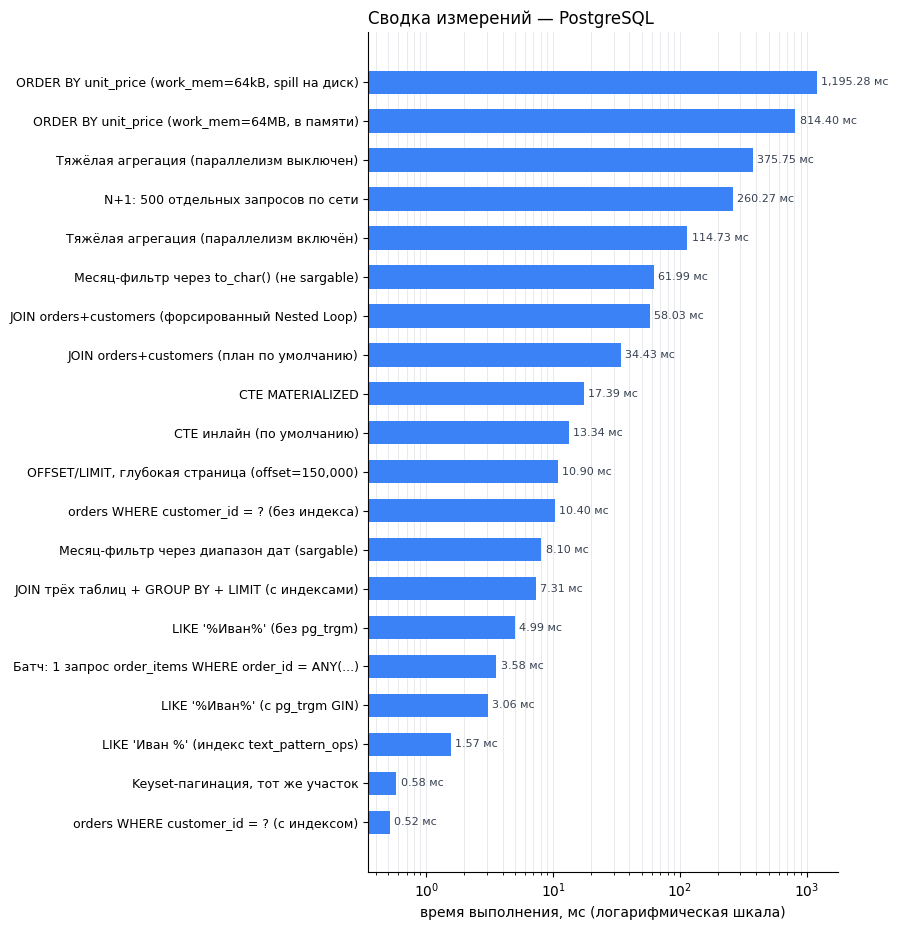

,experiment,time_ms,note
0,orders WHERE customer_id = ? (с индексом),0.5153,Bitmap Index/Heap Scan
1,"Keyset-пагинация, тот же участок",0.5816,
2,LIKE 'Иван %' (индекс text_pattern_ops),1.5686,Bitmap Index Scan
3,LIKE '%Иван%' (с pg_trgm GIN),3.0593,Bitmap Index Scan
4,Батч: 1 запрос order_items WHERE order_id = ANY(...),3.5783,1 round-trip
5,LIKE '%Иван%' (без pg_trgm),4.9884,Seq Scan
6,JOIN трёх таблиц + GROUP BY + LIMIT (с индексами),7.3123,
7,Месяц-фильтр через диапазон дат (sargable),8.0969,Bitmap Index/Heap Scan
8,orders WHERE customer_id = ? (без индекса),10.3987,Seq Scan
9,"OFFSET/LIMIT, глубокая страница (offset=150,000)",10.8969,


In [25]:
res_df = pd.DataFrame(results)
res_df = res_df.sort_values("time_ms", ascending=True).reset_index(drop=True)

ACCENT = "#3B82F6"

fig, ax = plt.subplots(figsize=(9, 0.42 * len(res_df) + 1))
y_pos = range(len(res_df))
ax.barh(y_pos, res_df["time_ms"], color=ACCENT, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(res_df["experiment"], fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("время выполнения, мс (логарифмическая шкала)")
ax.set_title("Сводка измерений — PostgreSQL", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", which="both", color="#e5e7eb", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

for i, v in enumerate(res_df["time_ms"]):
    ax.text(v * 1.08, i, f"{v:,.2f} мс", va="center", fontsize=8, color="#374151")

plt.tight_layout()
plt.show()

res_df

## 18. Памятка и отличия от SQLite-версии

**Того же самого, что и в SQLite-версии, но теперь на реальном сервере:**

- Full scan vs индекс, sargable-выражения, leftmost prefix, keyset-пагинация, N+1 — все выводы
  из SQLite-ноутбука остаются в силе один в один.

**То, чего в SQLite нет вообще:**

| Возможность | Зачем |
|---|---|
| `EXPLAIN (ANALYZE, BUFFERS)` | реальное время и реальные обращения к страницам, а не только оценка |
| Несколько алгоритмов JOIN (Nested Loop / Hash / Merge) | выбор зависит от объёма данных и наличия индексов, а не единственный вариант |
| `work_mem` и spill сортировок/хешей на диск | видно, когда запросу не хватает памяти на операцию |
| `INCLUDE`-индексы + Index Only Scan | не читать таблицу вообще, если индекс покрывает запрос — но нужен свежий `VACUUM` |
| Partial-индексы | индексировать только нужное подмножество строк |
| `GIN`/`GiST`/`BRIN` | специализированные структуры под полнотекстовый поиск, `jsonb`, геометрию, огромные таблицы |
| `pg_trgm` | ускорение `LIKE '%...%'` и нечёткого поиска без переписывания запроса |
| MVCC / dead tuples / `VACUUM` / `autovacuum` | у PostgreSQL нет перезаписи строк на месте — это плата за многоверсионность и параллельный доступ |
| Параллельное выполнение (`Gather`, `Parallel Seq Scan`) | несколько процессов ОС считают один запрос совместно |
| `pg_stat_statements`, `auto_explain`, `pg_stat_user_tables/indexes` | системная статистика в проде, а не только план одного запроса |

**Практический чек-лист поверх того, что уже был в SQLite-ноутбуке:**

1. Смотрите `Buffers`, а не только время — время шумит от прогретости кеша, буферы — нет.
2. Если ожидаете `Index Only Scan`, а видите `Bitmap Heap Scan`/`Heap Fetches > 0` — проверьте
   `VACUUM`/`autovacuum` и подходит ли вообще выбранный тип сканирования под Index Only Scan.
3. Если сортировка/хеш "уходит в Disk" в плане — скорее всего, дело в `work_mem`, а не в
   отсутствии индекса.
4. Для регулярно фильтруемого маленького подмножества строк — рассмотрите partial-индекс, а не
   индекс по всей таблице.
5. Для больших таблиц с естественно упорядоченным по времени столбцом — BRIN может быть
   значительно компактнее B-tree, если данные физически коррелируют с этим столбцом.

## 19. Задания для самостоятельной работы

Используйте базу `optimization` в контейнере `tutor-pg-optimization` (переменная `conn` /
`cur` из этого ноутбука) и функции `explain()` / `time_query()` из раздела 2.

1. Найдите запрос, для которого PostgreSQL выбирает `Merge Join` (а не `Hash Join` или
   `Nested Loop`). Подсказка: `Merge Join` любит уже отсортированные по ключу соединения входы —
   попробуйте `JOIN` по столбцам, оба из которых участвуют в `ORDER BY`, или добавьте
   `SET enable_hashjoin = off; SET enable_nestloop = off;`.
2. Создайте индекс на выражение (`to_char(order_date, 'YYYY-MM')`) и убедитесь, что "плохой"
   (не sargable) запрос из раздела 4 начинает его использовать.
3. Повторите демонстрацию `work_mem` для `GROUP BY` вместо `ORDER BY` — найдите план с
   `HashAggregate` и посмотрите, при каком значении `work_mem` он вынужден делать `Batches > 1`.
4. Сравните `pg_stat_user_indexes.idx_scan` до и после серии запросов — какие из созданных в
   этом ноутбуке индексов вообще ни разу не были использованы? (Индексы, которые не используются,
   — чистые накладные расходы на запись, кандидаты на удаление.)
5. Изучите `EXPLAIN (ANALYZE, BUFFERS, FORMAT JSON)` вместо текстового формата — попробуйте
   распарсить результат в Python через `json.loads` и построить свою сводную таблицу по узлам
   плана вместо чтения текста глазами.
6. Установите `pg_stat_statements` (`CREATE EXTENSION pg_stat_statements`, требует добавить
   модуль в `shared_preload_libraries` при запуске контейнера) и найдите самые дорогие по
   суммарному времени запросы за сессию — это стандартный первый шаг диагностики в проде,
   когда неизвестно, какой именно запрос тормозит.

## 20. Управление контейнером

```bash
# остановить (данные внутри контейнера сохранятся)
docker stop tutor-pg-optimization

# запустить снова
docker start tutor-pg-optimization

# полностью удалить контейнер вместе с данными (после этого ноутбук нужно
# прогнать заново от начала, чтобы пересоздать схему и загрузить данные)
docker rm -f tutor-pg-optimization
```

Контейнер не использует volume — все данные живут только в его writable-слое. Это осознанный
выбор для учебного контейнера: `docker rm` полностью и однозначно возвращает вас в чистое
состояние, а сам ноутбук пересоздаёт схему и данные с нуля при каждом запуске с начала.

In [26]:
cur.close()
conn.close()
print("Соединение закрыто.")

Соединение закрыто.
